# Exploratory Data Analysis - Bluestock Mutual Fund Analytics

Reads from `bluestock_mf.db` (built by `scripts/load_to_sqlite.py`) and produces the
charts for the final report. Every figure is also saved to `reports/charts/` as PNG.

Contents:
1. NAV trends, 2022-2026
2. AUM growth by fund house
3. SIP inflows
4. Category flow heatmap
5. Investor demographics
6. Geographic distribution
7. Folio growth
8. Return correlation
9. Sector allocation
10. Ten key findings

Note on chart export: Plotly PNG export needs kaleido, whose browser backend does not
start on this machine (it hangs instead of raising, so try/except does not help). The two
Plotly figures are saved as interactive HTML and redrawn in matplotlib for the PNG.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "bluestock_mf.db"
CHARTS_DIR = PROJECT_ROOT / "reports" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

engine = create_engine(f"sqlite:///{DB_PATH}")


def run_query(sql):
    return pd.read_sql_query(sql, engine)


def save_png(fig, name):
    fig.savefig(CHARTS_DIR / f"{name}.png")
    print(f"  saved  reports/charts/{name}.png")


sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (13, 6), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 10,
})
pio.templates.default = "plotly_white"

PALETTE = ["#2E5EAA", "#E4572E", "#17A398", "#F3A712", "#8367C7",
           "#3F784C", "#C1292E", "#5B85AA", "#A67F5D", "#6B7A8F"]

print(f"database : {DB_PATH}")
print(f"charts   : {CHARTS_DIR}")

database : C:\Users\hi\Documents\MutualFundAnalytics\bluestock_mf.db
charts   : C:\Users\hi\Documents\MutualFundAnalytics\reports\charts


## Load data

In [2]:
nav = run_query('''
    SELECT n.amfi_code, n.date_key, n.nav, n.daily_return,
           f.scheme_name, f.fund_house, f.category, f.sub_category, f.plan,
           f.expense_ratio_pct
    FROM fact_nav n JOIN dim_fund f ON f.amfi_code = n.amfi_code
''')
nav["date_key"] = pd.to_datetime(nav["date_key"])
nav["year"] = nav["date_key"].dt.year

fund = run_query("SELECT * FROM dim_fund")
perf = run_query("SELECT p.*, f.scheme_name, f.fund_house, f.sub_category, f.plan "
                 "FROM fact_performance p JOIN dim_fund f ON f.amfi_code = p.amfi_code")
aum = run_query("SELECT * FROM fact_aum")
sip = run_query("SELECT * FROM fact_sip_inflows ORDER BY month_start")
cat = run_query("SELECT * FROM fact_category_inflows")
fol = run_query("SELECT * FROM fact_folio_count ORDER BY month_start")
txn = run_query("SELECT * FROM fact_transactions")
hold = run_query("SELECT h.*, f.category FROM fact_holdings h "
                 "JOIN dim_fund f ON f.amfi_code = h.amfi_code")
bench = run_query("SELECT * FROM fact_benchmark")

bench["date_key"] = pd.to_datetime(bench["date_key"])
txn["date_key"] = pd.to_datetime(txn["date_key"])
txn["month"] = txn["date_key"].dt.to_period("M").astype(str)
aum["date_key"] = pd.to_datetime(aum["date_key"])

print(f"nav      {nav.shape[0]:>7,} rows   {nav.amfi_code.nunique()} schemes  "
      f"{nav.date_key.min():%Y-%m-%d} -> {nav.date_key.max():%Y-%m-%d}")
print(f"txn      {txn.shape[0]:>7,} rows   {txn.investor_id.nunique():,} investors")
print(f"bench    {bench.shape[0]:>7,} rows   {bench.index_name.nunique()} indices")
print(f"holdings {hold.shape[0]:>7,} rows   {hold.amfi_code.nunique()} schemes")

nav       46,000 rows   40 schemes  2022-01-03 -> 2026-05-29
txn       32,778 rows   5,000 investors
bench      8,050 rows   7 indices
holdings     322 rows   34 schemes


## 1. NAV trend, 2022-2026

Daily NAV for all 40 schemes, with the 2023 bull run and the 2024 correction shaded.
Note that in this dataset the funds do not actually correct in 2024 even though the
benchmark does - see finding 10.

In [3]:
BULL_2023 = ("2023-01-01", "2023-12-31")
CORR_2024 = ("2024-01-01", "2024-12-31")

fig = go.Figure()
for i, (code, g) in enumerate(nav.groupby("amfi_code")):
    g = g.sort_values("date_key")
    fig.add_trace(go.Scatter(
        x=g["date_key"], y=g["nav"], mode="lines", name=g["scheme_name"].iloc[0],
        line=dict(width=1), opacity=0.75,
        hovertemplate="%{fullData.name}<br>%{x|%d %b %Y}<br>NAV %{y:.2f}<extra></extra>",
    ))

for (x0, x1), colour, label in [
    (BULL_2023, "rgba(23,163,152,0.13)", "2023 bull run"),
    (CORR_2024, "rgba(228,87,46,0.13)", "2024 correction"),
]:
    fig.add_vrect(x0=x0, x1=x1, fillcolor=colour, line_width=0, layer="below",
                  annotation_text=label, annotation_position="top left")

fig.update_layout(
    title="Daily NAV - all 40 schemes (2022-2026)",
    xaxis_title="Date", yaxis_title="NAV (Rs)", yaxis_type="log",
    height=650, showlegend=False, hovermode="closest",
)
fig.write_html(CHARTS_DIR / "01_nav_trend_all_schemes.html", include_plotlyjs="cdn")
print("  saved  reports/charts/01_nav_trend_all_schemes.html")
print("  (matplotlib version below is the one exported as PNG)")

  saved  reports/charts/01_nav_trend_all_schemes.html
  (matplotlib version below is the one exported as PNG)


NAV is on a log scale. The schemes range from about Rs 20 to Rs 6,000, so on a linear
axis the three most expensive lines flatten the other 37 into an unreadable band. On a
log axis equal vertical distance means equal percentage change.

  saved  reports/charts/01_nav_trend_all_schemes_static.png


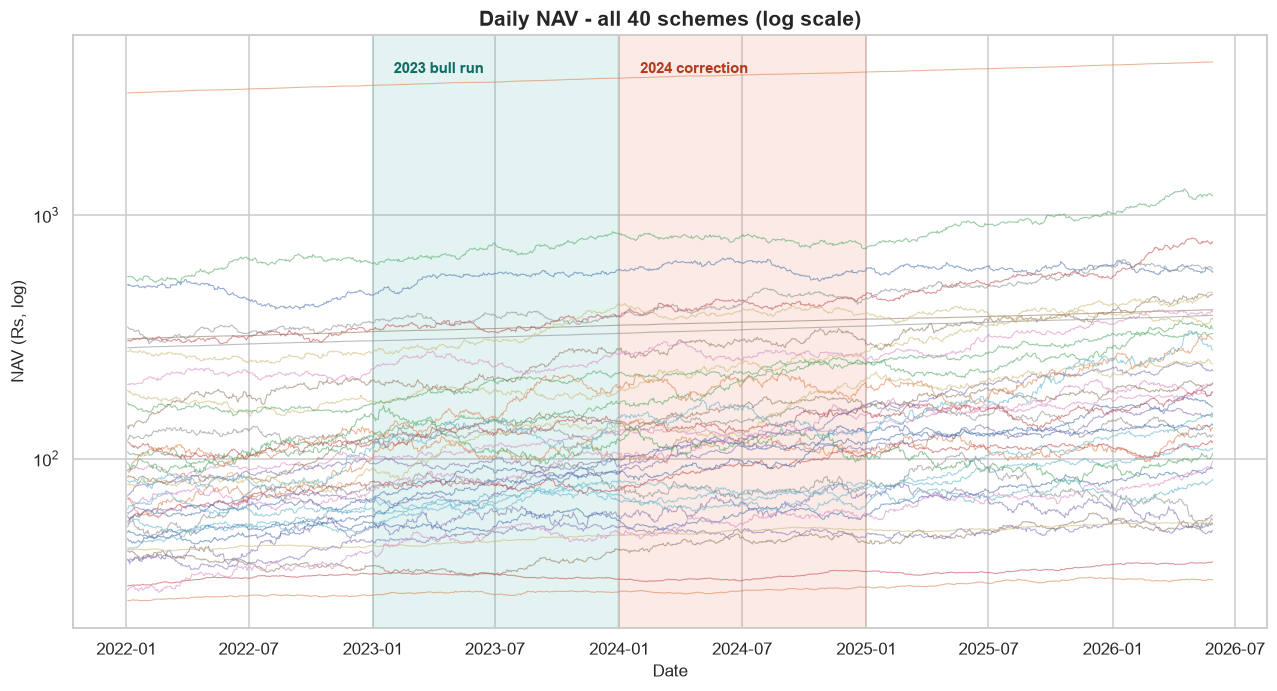

In [4]:
# matplotlib version of the chart above, for the PNG in the report
fig, ax = plt.subplots(figsize=(14, 7))
for code, g in nav.groupby("amfi_code"):
    g = g.sort_values("date_key")
    ax.plot(g["date_key"], g["nav"], lw=0.7, alpha=0.6)
ax.axvspan(pd.Timestamp(BULL_2023[0]), pd.Timestamp(BULL_2023[1]), color="#17A398", alpha=0.12)
ax.axvspan(pd.Timestamp(CORR_2024[0]), pd.Timestamp(CORR_2024[1]), color="#E4572E", alpha=0.12)
ax.text(pd.Timestamp("2023-02-01"), nav.nav.max() * 0.9, "2023 bull run",
        color="#0F6E66", fontweight="bold")
ax.text(pd.Timestamp("2024-02-01"), nav.nav.max() * 0.9, "2024 correction",
        color="#B33C1C", fontweight="bold")
ax.set_yscale("log")
ax.set(title="Daily NAV - all 40 schemes (log scale)", xlabel="Date", ylabel="NAV (Rs, log)")
save_png(fig, "01_nav_trend_all_schemes_static")
plt.show()

## 2. Rebased NAV vs benchmark

Every scheme and the NIFTY 50 rebased to 100 at 2022-01-03 so they can be compared
directly. The fund NAVs and the benchmark move independently, which affects every
risk metric computed in the performance notebook.

  saved  reports/charts/02_rebased_nav_vs_benchmark.png


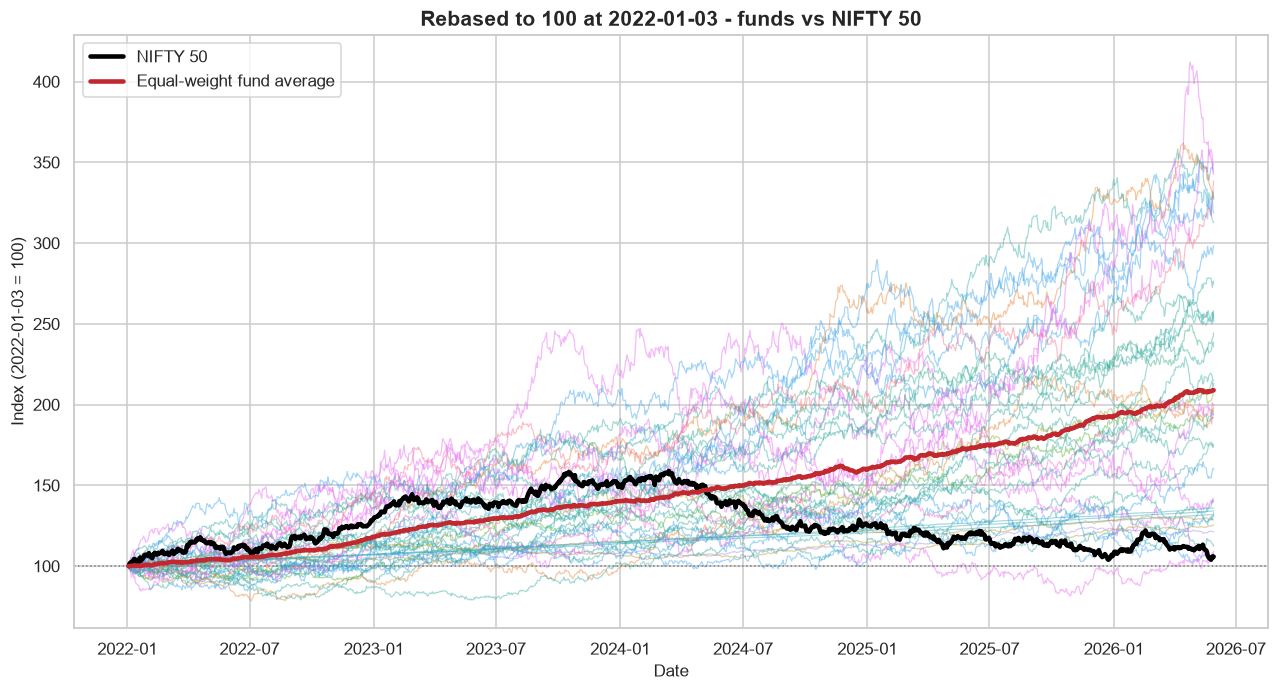

Calendar-year return, % :
      fund_equal_weight  nifty50
year                            
2022              18.08    28.32
2023              19.18    14.44
2024              13.69   -15.69
2025              19.66   -14.82
2026               7.34    -1.55


In [5]:
def rebase(s):
    return 100 * s / s.iloc[0]


fig, ax = plt.subplots(figsize=(14, 7))
cat_colours = dict(zip(sorted(nav.sub_category.unique()),
                       sns.color_palette("husl", nav.sub_category.nunique())))
for code, g in nav.groupby("amfi_code"):
    g = g.sort_values("date_key")
    ax.plot(g["date_key"], rebase(g["nav"]), lw=0.8, alpha=0.45,
            color=cat_colours[g["sub_category"].iloc[0]])

n50 = bench[bench.index_name == "NIFTY50"].sort_values("date_key")
ax.plot(n50["date_key"], rebase(n50["close_value"]), lw=3, color="black",
        label="NIFTY 50", zorder=5)

eq = nav.pivot_table(index="date_key", columns="amfi_code", values="nav").apply(rebase).mean(axis=1)
ax.plot(eq.index, eq.values, lw=3, color="#C1292E", label="Equal-weight fund average", zorder=6)

ax.axhline(100, color="grey", ls=":", lw=1)
ax.set(title="Rebased to 100 at 2022-01-03 - funds vs NIFTY 50",
       xlabel="Date", ylabel="Index (2022-01-03 = 100)")
ax.legend(loc="upper left")
save_png(fig, "02_rebased_nav_vs_benchmark")
plt.show()

comp = pd.DataFrame({
    "fund_equal_weight": nav.groupby("year").apply(
        lambda d: (d.groupby("amfi_code").nav.last() / d.groupby("amfi_code").nav.first() - 1).mean() * 100),
    "nifty50": bench[bench.index_name == "NIFTY50"].assign(year=lambda d: d.date_key.dt.year)
        .groupby("year").close_value.apply(lambda s: (s.iloc[-1] / s.iloc[0] - 1) * 100),
}).round(2)
print("Calendar-year return, % :")
print(comp.to_string())

## 3. AUM growth by fund house

  saved  reports/charts/03_aum_by_fund_house.png

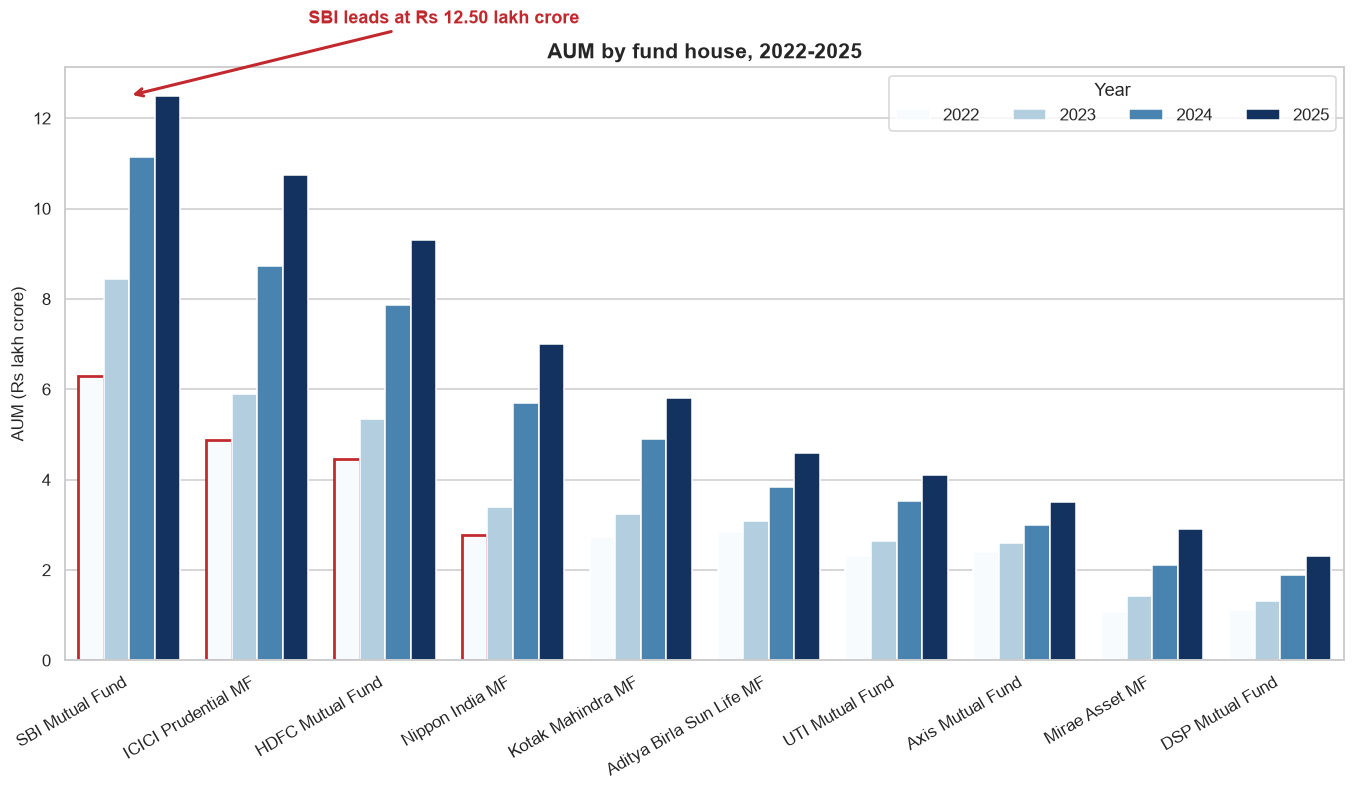

In [6]:
aum["year"] = aum["date_key"].dt.year
yearly = (aum[aum.year.between(2022, 2025)]
          .sort_values("date_key").groupby(["fund_house", "year"], as_index=False)
          .last())
order = (yearly[yearly.year == yearly.year.max()]
         .sort_values("aum_lakh_crore", ascending=False)["fund_house"].tolist())

fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(data=yearly, x="fund_house", y="aum_lakh_crore", hue="year",
            order=order, palette="Blues", ax=ax)

# call out SBI, which leads the whole window
sbi_peak = yearly[yearly.fund_house == "SBI Mutual Fund"]["aum_lakh_crore"].max()
ax.annotate(f"SBI leads at Rs {sbi_peak:.2f} lakh crore",
            xy=(0, sbi_peak), xytext=(1.4, sbi_peak + 1.6),
            arrowprops=dict(arrowstyle="->", color="#C1292E", lw=2),
            fontsize=12, fontweight="bold", color="#C1292E")
for patch in ax.patches[:4]:
    patch.set_edgecolor("#C1292E")
    patch.set_linewidth(1.8)

ax.set(title="AUM by fund house, 2022-2025", xlabel="", ylabel="AUM (Rs lakh crore)")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")
ax.legend(title="Year", ncol=4)
save_png(fig, "03_aum_by_fund_house")
plt.show()

## 4. Monthly SIP inflows, Jan 2022 - Dec 2025

  saved  reports/charts/04_sip_inflow_timeseries.html


  saved  reports/charts/04_sip_inflow_timeseries_static.png


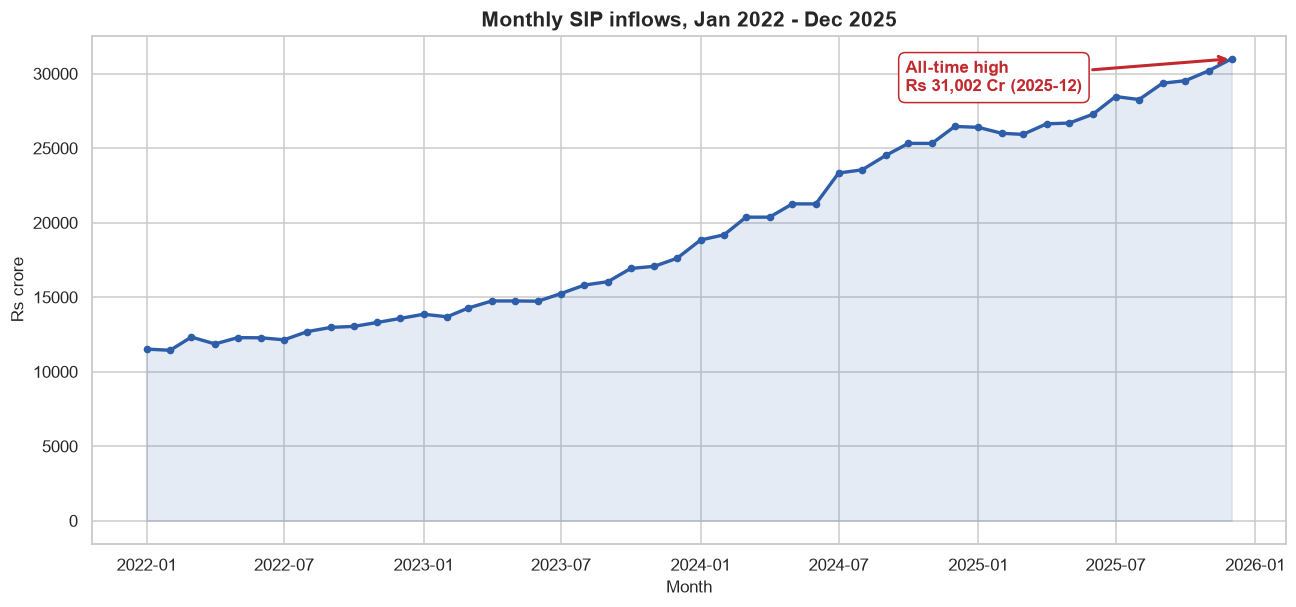

Jan 2022: Rs 11,517 Cr  ->  Dec 2025: Rs 31,002 Cr  (+169.2%)


In [7]:
sip["month_start"] = pd.to_datetime(sip["month_start"])
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sip["month_start"], y=sip["sip_inflow_crore"], mode="lines+markers",
    name="Monthly SIP inflow", line=dict(color="#2E5EAA", width=3),
    marker=dict(size=5),
    hovertemplate="%{x|%b %Y}<br>Rs %{y:,.0f} Cr<extra></extra>",
))
fig.add_annotation(
    x=peak["month_start"], y=peak["sip_inflow_crore"],
    text=f"All-time high<br>Rs {peak['sip_inflow_crore']:,.0f} Cr<br>({peak['month']})",
    showarrow=True, arrowhead=2, arrowsize=1.2, arrowcolor="#C1292E",
    ax=-90, ay=-70, font=dict(size=13, color="#C1292E"),
    bordercolor="#C1292E", borderwidth=2, bgcolor="rgba(255,255,255,0.9)",
)
fig.update_layout(title="Monthly SIP inflows, Jan 2022 - Dec 2025",
                  xaxis_title="Month", yaxis_title="SIP inflow (Rs crore)", height=550)
fig.write_html(CHARTS_DIR / "04_sip_inflow_timeseries.html", include_plotlyjs="cdn")
print("  saved  reports/charts/04_sip_inflow_timeseries.html")

fig2, ax = plt.subplots(figsize=(14, 6))
ax.plot(sip["month_start"], sip["sip_inflow_crore"], marker="o", ms=4, lw=2.2, color="#2E5EAA")
ax.fill_between(sip["month_start"], sip["sip_inflow_crore"], alpha=0.12, color="#2E5EAA")
ax.annotate(f"All-time high\nRs {peak['sip_inflow_crore']:,.0f} Cr ({peak['month']})",
            xy=(peak["month_start"], peak["sip_inflow_crore"]),
            xytext=(peak["month_start"] - pd.Timedelta(days=430), peak["sip_inflow_crore"] * 0.93),
            arrowprops=dict(arrowstyle="->", color="#C1292E", lw=2),
            fontsize=11, fontweight="bold", color="#C1292E",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#C1292E"))
ax.set(title="Monthly SIP inflows, Jan 2022 - Dec 2025", xlabel="Month", ylabel="Rs crore")
save_png(fig2, "04_sip_inflow_timeseries_static")
plt.show()

print(f"Jan 2022: Rs {sip.sip_inflow_crore.iloc[0]:,.0f} Cr  ->  "
      f"Dec 2025: Rs {sip.sip_inflow_crore.iloc[-1]:,.0f} Cr  "
      f"({sip.sip_inflow_crore.iloc[-1] / sip.sip_inflow_crore.iloc[0] - 1:+.1%})")

### 4b. SIP year-on-year growth

  saved  reports/charts/05_sip_yoy_growth.png


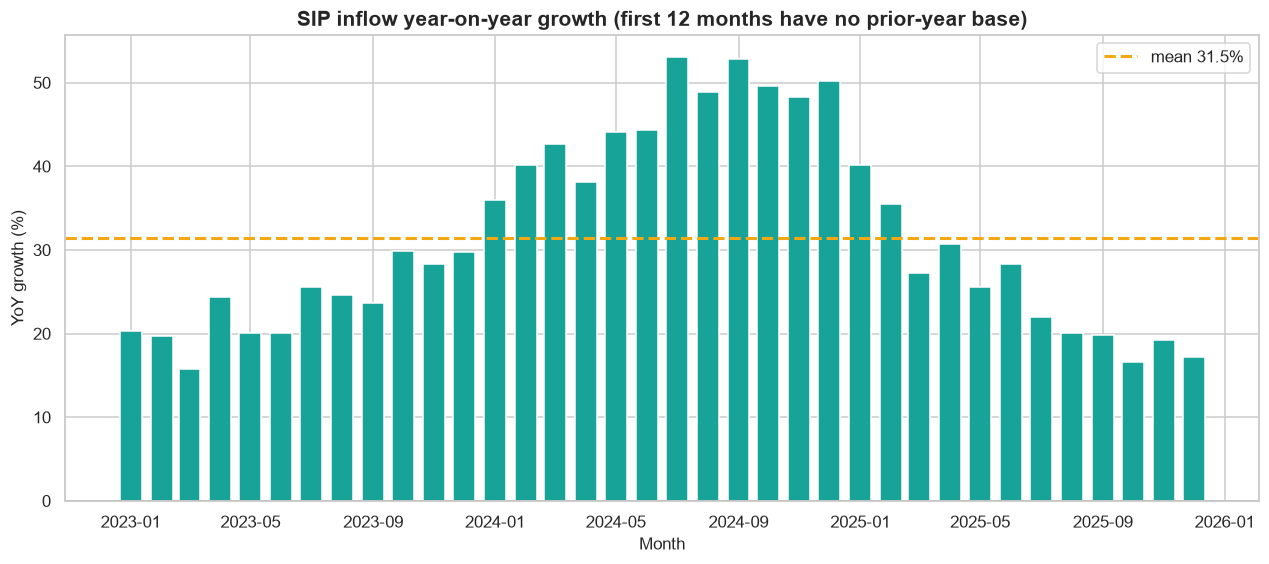

In [8]:
fig, ax = plt.subplots(figsize=(14, 5.5))
d = sip.dropna(subset=["yoy_growth_pct"])
colours = ["#17A398" if v >= 0 else "#C1292E" for v in d["yoy_growth_pct"]]
ax.bar(d["month_start"], d["yoy_growth_pct"], width=22, color=colours)
ax.axhline(0, color="black", lw=1)
ax.axhline(d["yoy_growth_pct"].mean(), color="#F3A712", ls="--", lw=2,
           label=f"mean {d['yoy_growth_pct'].mean():.1f}%")
ax.set(title="SIP inflow year-on-year growth (first 12 months have no prior-year base)",
       xlabel="Month", ylabel="YoY growth (%)")
ax.legend()
save_png(fig, "05_sip_yoy_growth")
plt.show()

## 5. Category inflow heatmap

  saved  reports/charts/06_category_inflow_heatmap.png


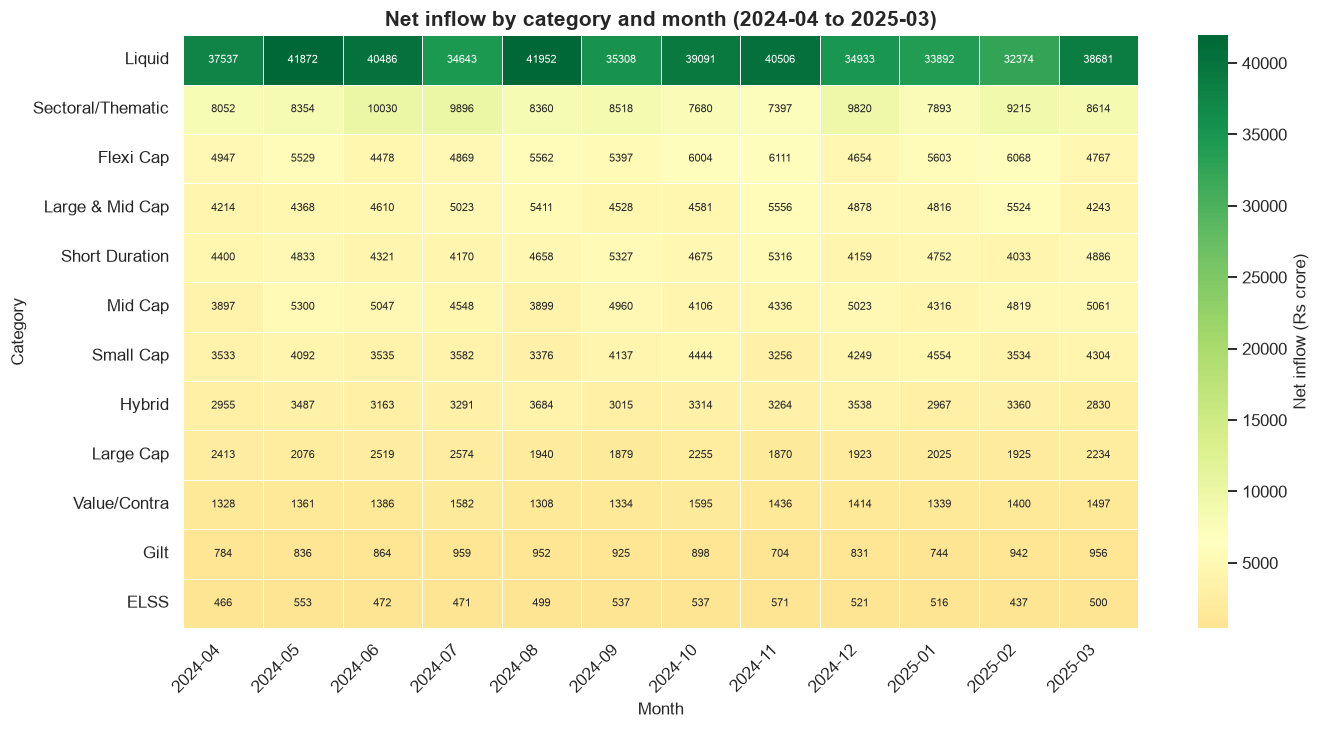

coverage: 12 months x 12 categories
negative (outflow) cells: 0 of 144


In [9]:
pivot = cat.pivot_table(index="category", columns="month", values="net_inflow_crore", aggfunc="sum")
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, cmap="RdYlGn", center=pivot.values.mean(), annot=True, fmt=".0f",
            annot_kws={"size": 7.5}, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Net inflow (Rs crore)"}, ax=ax)
ax.set(title=f"Net inflow by category and month ({pivot.columns[0]} to {pivot.columns[-1]})",
       xlabel="Month", ylabel="Category")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
save_png(fig, "06_category_inflow_heatmap")
plt.show()

print(f"coverage: {pivot.shape[1]} months x {pivot.shape[0]} categories")
print(f"negative (outflow) cells: {int((pivot < 0).sum().sum())} of {pivot.size}")

## 6. Investor demographics

  saved  reports/charts/07_demographics_age_gender.png


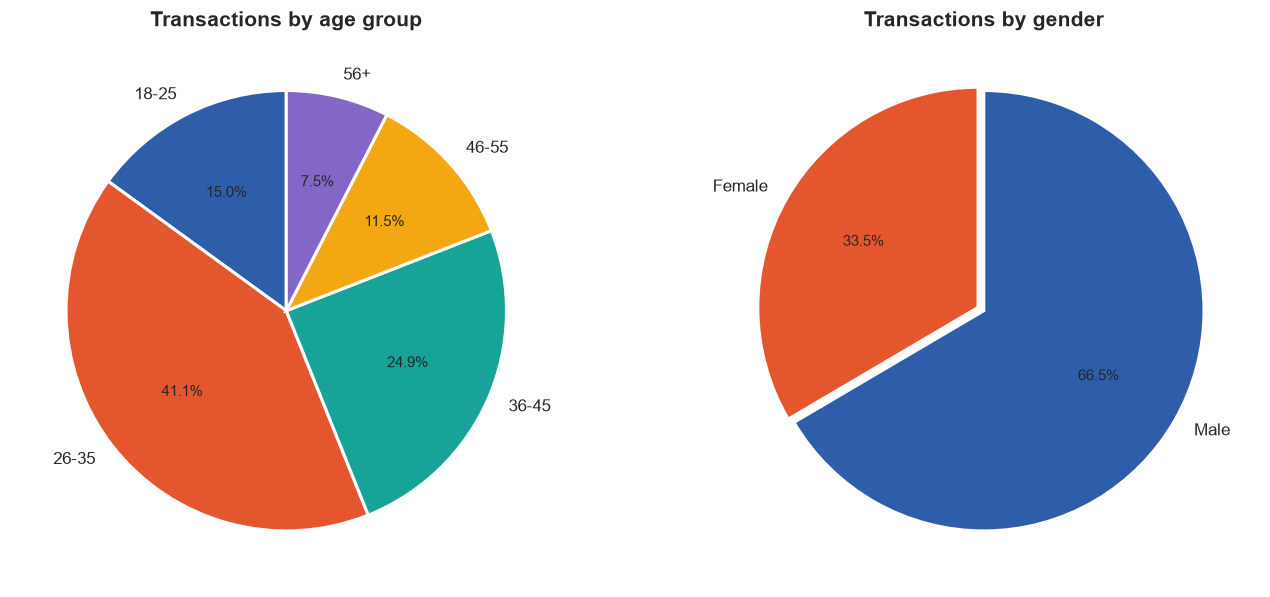

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

age = txn.groupby("age_group").size().sort_index()
axes[0].pie(age.values, labels=age.index, autopct="%1.1f%%", startangle=90,
            colors=PALETTE[:len(age)], wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Transactions by age group")

gender = txn.groupby("gender").size()
axes[1].pie(gender.values, labels=gender.index, autopct="%1.1f%%", startangle=90,
            colors=["#E4572E", "#2E5EAA"], wedgeprops=dict(edgecolor="white", linewidth=2),
            explode=[0.03, 0])
axes[1].set_title("Transactions by gender")

save_png(fig, "07_demographics_age_gender")
plt.show()

  saved  reports/charts/08_sip_amount_by_age.png

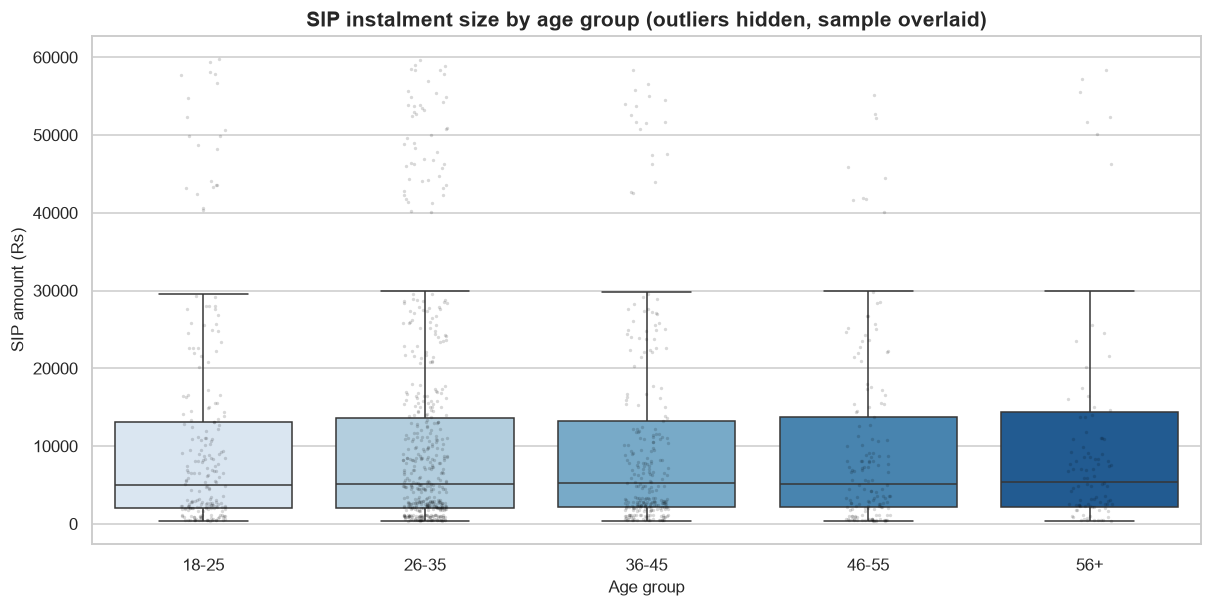

           count  median     mean
age_group                        
18-25       2949  5020.0  10953.0
26-35       8063  5070.0  10987.0
36-45       4926  5250.0  10886.0
46-55       2300  5136.0  11137.0
56+         1478  5420.0  11575.0


In [11]:
fig, ax = plt.subplots(figsize=(13, 6))
sip_txn = txn[txn.transaction_type == "SIP"]
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr",
            order=sorted(sip_txn.age_group.unique()), palette="Blues", ax=ax, showfliers=False)
sns.stripplot(data=sip_txn.sample(min(1200, len(sip_txn)), random_state=0),
              x="age_group", y="amount_inr", order=sorted(sip_txn.age_group.unique()),
              color="black", alpha=0.15, size=2.2, ax=ax)
ax.set(title="SIP instalment size by age group (outliers hidden, sample overlaid)",
       xlabel="Age group", ylabel="SIP amount (Rs)")
save_png(fig, "08_sip_amount_by_age")
plt.show()

print(sip_txn.groupby("age_group").amount_inr.agg(["count", "median", "mean"]).round(0).to_string())

## 7. Geographic distribution

  saved  reports/charts/09_geographic_distribution.png


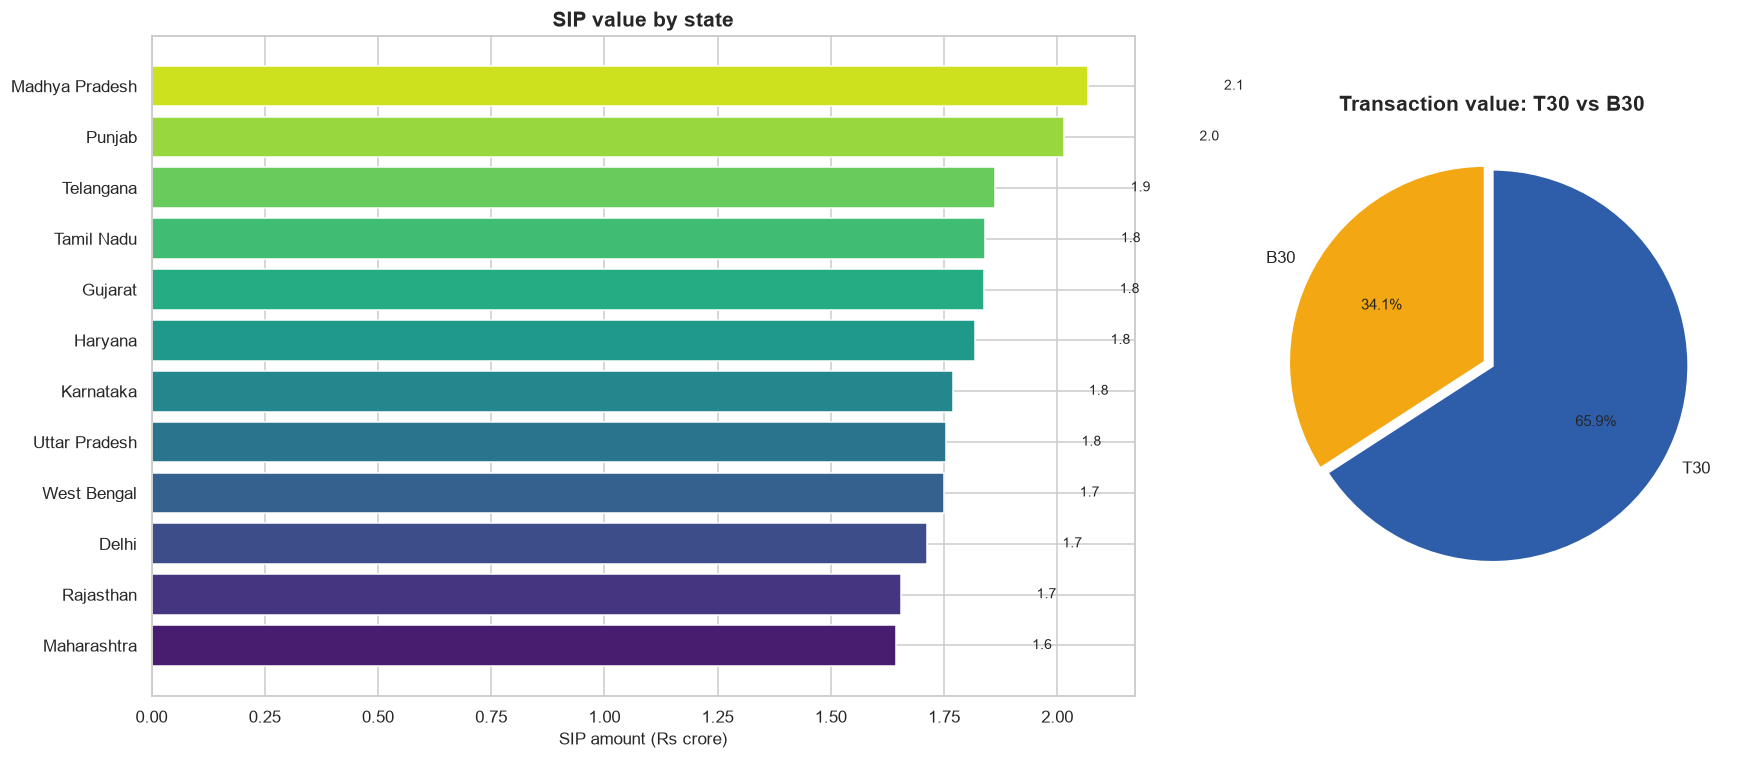

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [2, 1]})

state = (txn[txn.transaction_type == "SIP"].groupby("state").amount_inr.sum() / 1e7).sort_values()
axes[0].barh(state.index, state.values, color=sns.color_palette("viridis", len(state)))
axes[0].set(title="SIP value by state", xlabel="SIP amount (Rs crore)", ylabel="")
for i, v in enumerate(state.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=9)

tier = txn.groupby("city_tier").amount_inr.sum()
axes[1].pie(tier.values, labels=tier.index, autopct="%1.1f%%", startangle=90,
            colors=["#F3A712", "#2E5EAA"], wedgeprops=dict(edgecolor="white", linewidth=2),
            explode=[0.04, 0])
axes[1].set_title("Transaction value: T30 vs B30")

plt.tight_layout()
save_png(fig, "09_geographic_distribution")
plt.show()

## 8. Folio count growth

  saved  reports/charts/10_folio_growth.png


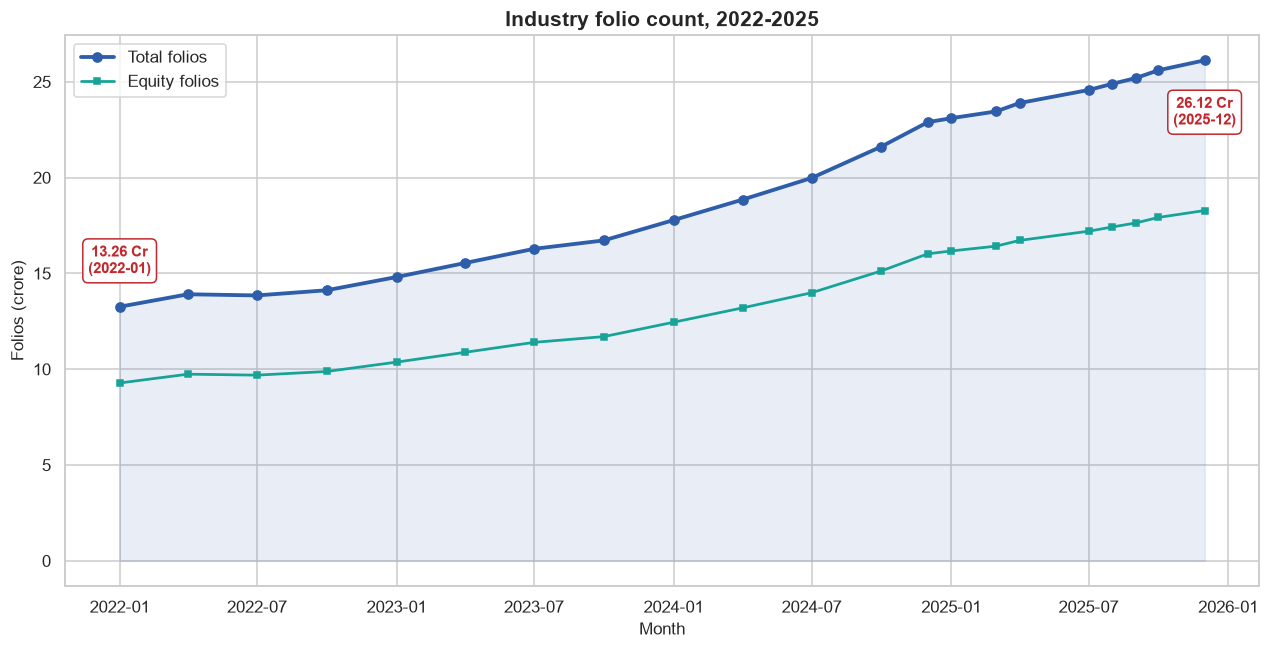

2022-01: 13.26 Cr -> 2025-12: 26.12 Cr (+97.0%)
observations: 21 across 2022-01 - 2025-12 (irregular cadence)


In [13]:
fol["month_start"] = pd.to_datetime(fol["month_start"])
fig, ax = plt.subplots(figsize=(14, 6.5))
ax.plot(fol["month_start"], fol["total_folios_crore"], marker="o", lw=2.5,
        color="#2E5EAA", label="Total folios")
ax.fill_between(fol["month_start"], fol["total_folios_crore"], alpha=0.10, color="#2E5EAA")
ax.plot(fol["month_start"], fol["equity_folios_crore"], marker="s", ms=4, lw=1.8,
        color="#17A398", label="Equity folios")

for idx in [0, len(fol) - 1]:
    r = fol.iloc[idx]
    ax.annotate(f"{r['total_folios_crore']:.2f} Cr\n({r['month']})",
                xy=(r["month_start"], r["total_folios_crore"]),
                xytext=(0, 22 if idx == 0 else -42), textcoords="offset points",
                ha="center", fontweight="bold", color="#C1292E",
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#C1292E"))

ax.set(title="Industry folio count, 2022-2025", xlabel="Month", ylabel="Folios (crore)")
ax.legend()
save_png(fig, "10_folio_growth")
plt.show()

print(f"{fol.month.iloc[0]}: {fol.total_folios_crore.iloc[0]} Cr -> "
      f"{fol.month.iloc[-1]}: {fol.total_folios_crore.iloc[-1]} Cr "
      f"({fol.total_folios_crore.iloc[-1] / fol.total_folios_crore.iloc[0] - 1:+.1%})")
print(f"observations: {len(fol)} across {fol.month.iloc[0]} - {fol.month.iloc[-1]} (irregular cadence)")

## 9. Daily-return correlation matrix

Pairwise correlation of daily returns for the 10 largest schemes by AUM.

  saved  reports/charts/11_return_correlation_matrix.png


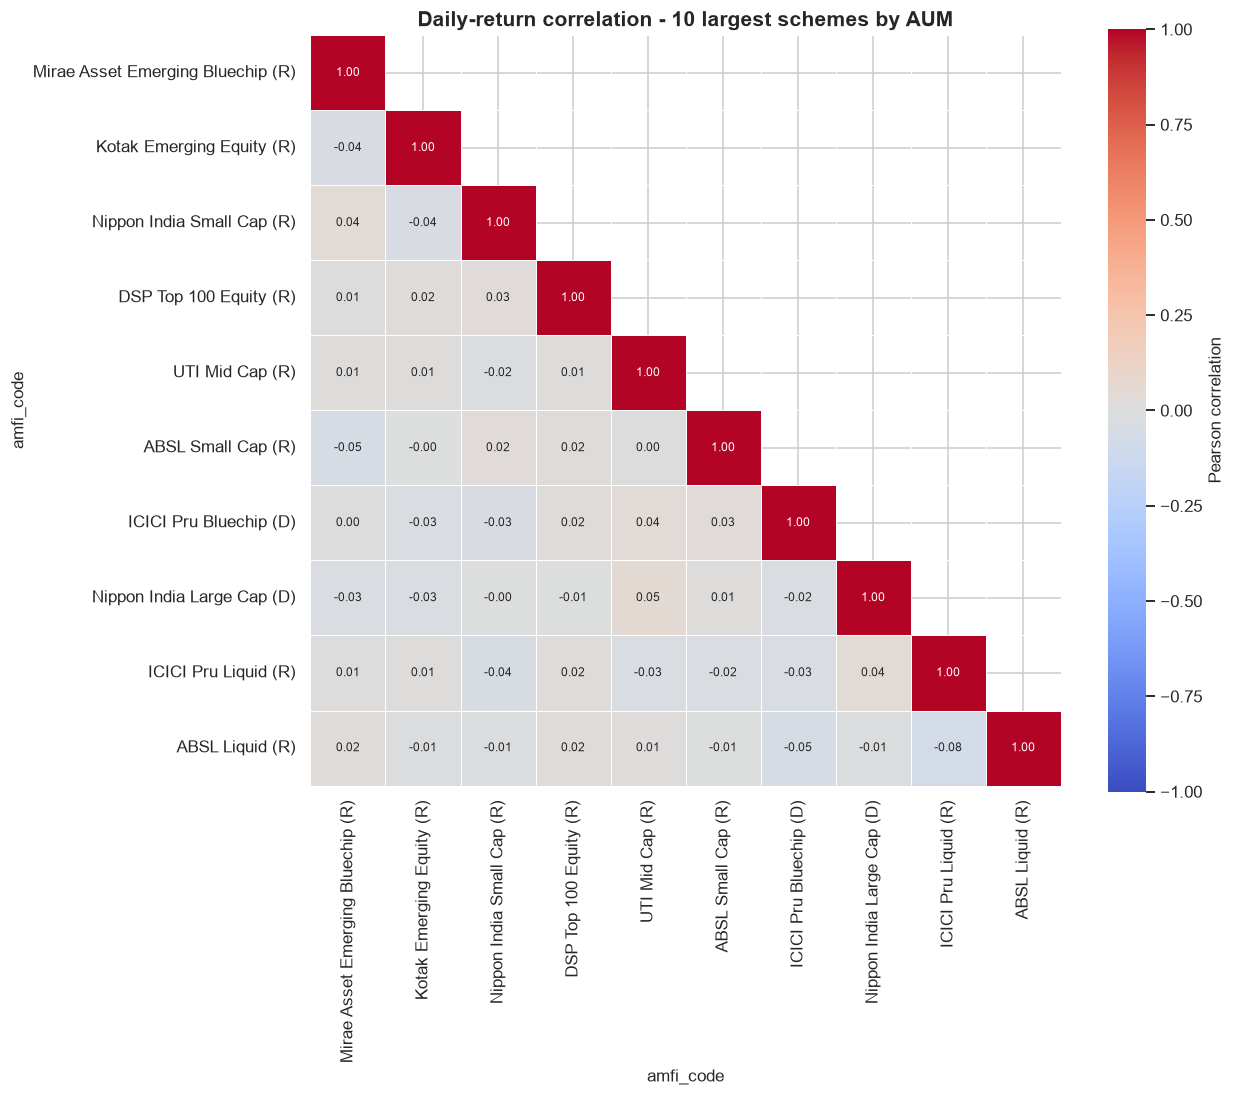

mean pairwise correlation : -0.0027
range                     : -0.076 to +0.052

Real large-cap equity funds in one market usually correlate 0.75-0.95.


In [14]:
top10 = perf.nlargest(10, "aum_crore")["amfi_code"].tolist()
labels = (perf.set_index("amfi_code").loc[top10, "scheme_name"]
          .str.replace(" Fund", "", regex=False)
          .str.replace(" - Regular Plan - Growth", " (R)", regex=False)
          .str.replace(" - Direct Plan - Growth", " (D)", regex=False)
          .str.replace(" - Regular - Growth", " (R)", regex=False)
          .str.replace(" - Direct - Growth", " (D)", regex=False))

rets = (nav[nav.amfi_code.isin(top10)]
        .pivot_table(index="date_key", columns="amfi_code", values="daily_return"))
rets = rets[top10].rename(columns=labels)
corr = rets.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}, square=True,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Daily-return correlation - 10 largest schemes by AUM")
save_png(fig, "11_return_correlation_matrix")
plt.show()

off = corr.values[np.triu_indices_from(corr, k=1)]
print(f"mean pairwise correlation : {off.mean():+.4f}")
print(f"range                     : {off.min():+.3f} to {off.max():+.3f}")
print("\nReal large-cap equity funds in one market usually correlate 0.75-0.95.")

## 10. Sector allocation

  saved  reports/charts/12_sector_allocation_donut.png


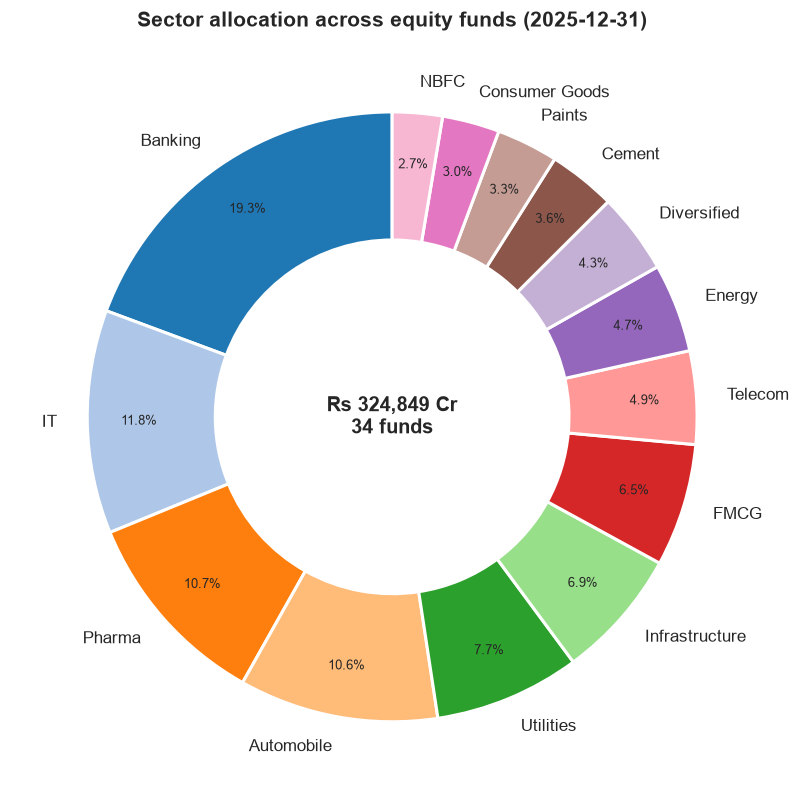

sector
Banking           19.34
IT                11.84
Pharma            10.65
Automobile        10.56
Utilities          7.73
Infrastructure     6.91
FMCG               6.51
Telecom            4.94
Energy             4.71
Diversified        4.28
Cement             3.57
Paints             3.27
Consumer Goods     3.04
NBFC               2.65


In [15]:
sector = (hold[hold.category == "Equity"].groupby("sector")["market_value_cr"].sum()
          .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(11, 9))
wedges, _, autotexts = ax.pie(
    sector.values, labels=sector.index, autopct="%1.1f%%", startangle=90, pctdistance=0.83,
    colors=sns.color_palette("tab20", len(sector)),
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
)
for t in autotexts:
    t.set_fontsize(8.5)
ax.text(0, 0, f"Rs {sector.sum():,.0f} Cr\n{hold.amfi_code.nunique()} funds",
        ha="center", va="center", fontsize=13, fontweight="bold")
ax.set_title("Sector allocation across equity funds (2025-12-31)")
save_png(fig, "12_sector_allocation_donut")
plt.show()

print((100 * sector / sector.sum()).round(2).to_string())

## 11. Supporting charts

  saved  reports/charts/13_supporting_charts.png


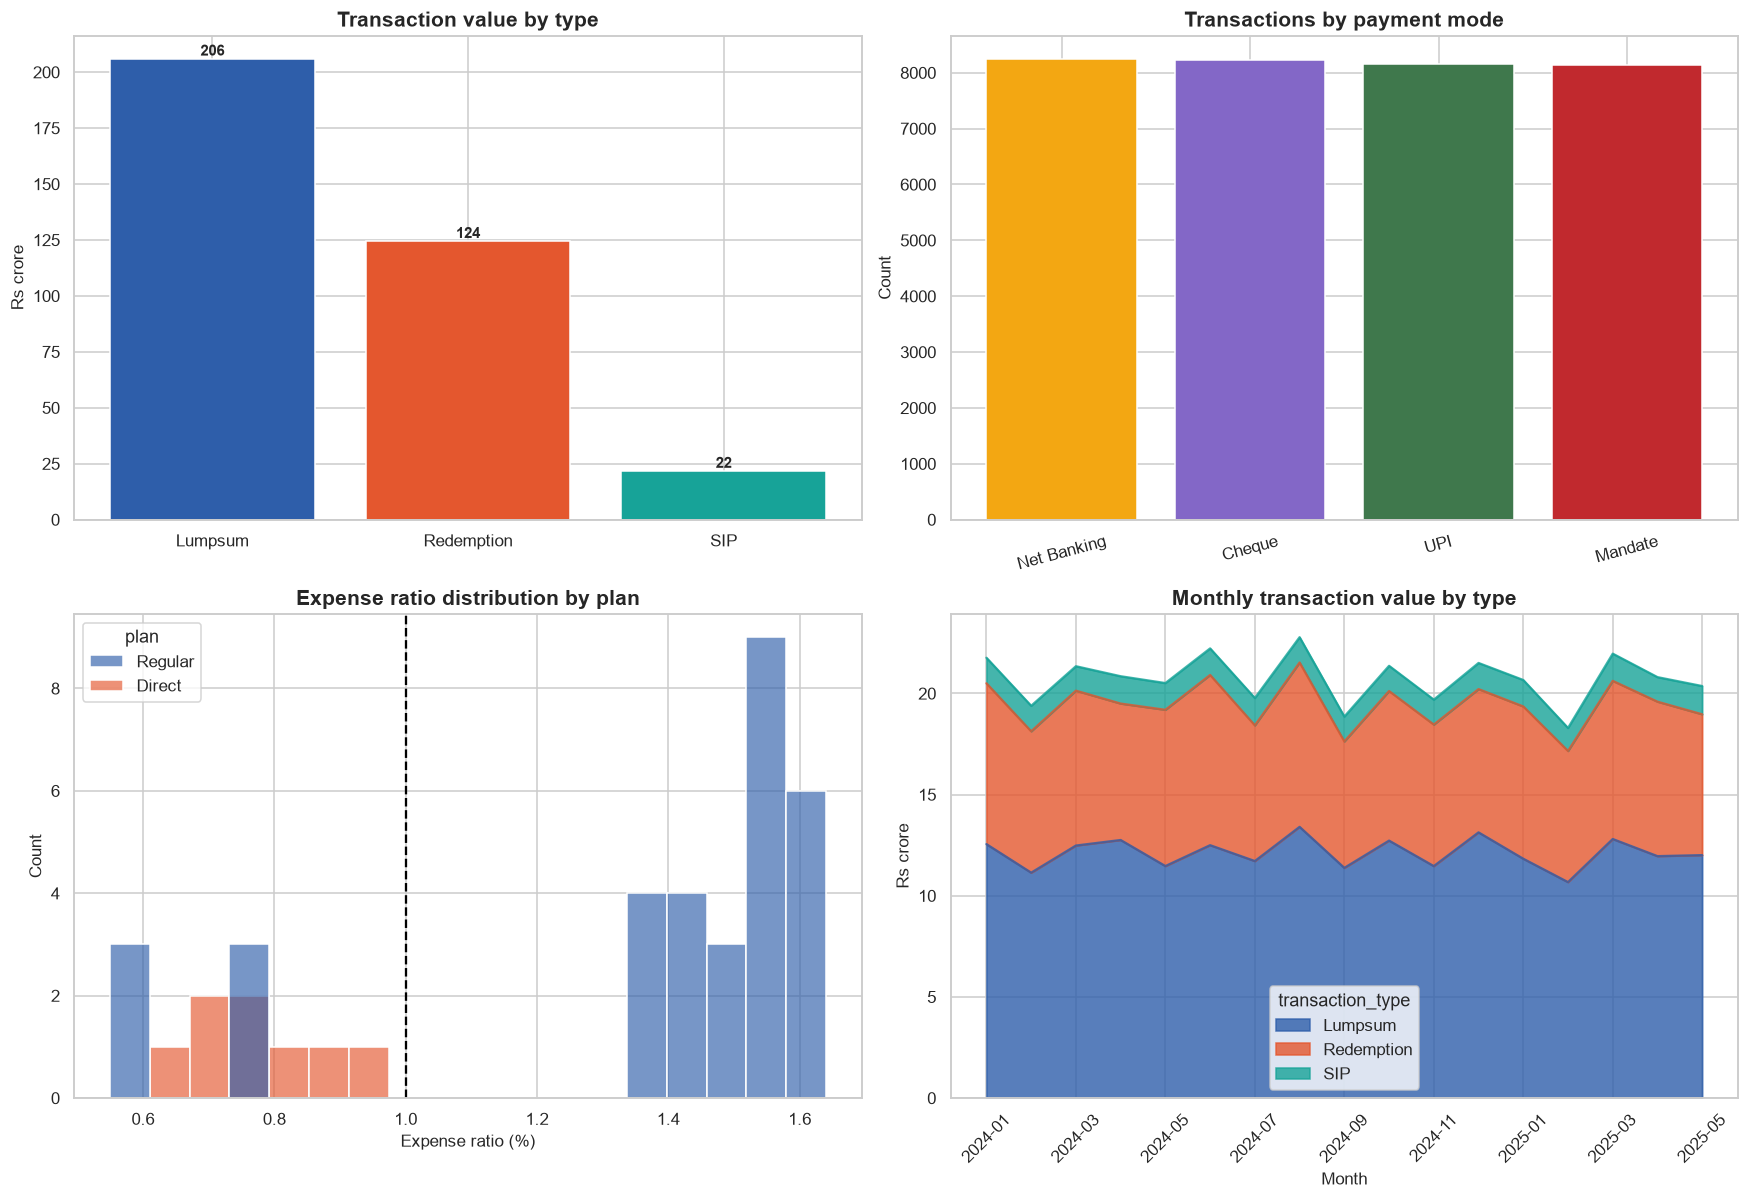

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

mix = txn.groupby("transaction_type").amount_inr.sum() / 1e7
axes[0, 0].bar(mix.index, mix.values, color=PALETTE[:3])
axes[0, 0].set(title="Transaction value by type", ylabel="Rs crore")
for i, v in enumerate(mix.values):
    axes[0, 0].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontweight="bold")

pay = txn.payment_mode.value_counts()
axes[0, 1].bar(pay.index, pay.values, color=PALETTE[3:7])
axes[0, 1].set(title="Transactions by payment mode", ylabel="Count")
axes[0, 1].tick_params(axis="x", rotation=15)

sns.histplot(data=fund, x="expense_ratio_pct", hue="plan", bins=18, multiple="layer",
             palette=["#2E5EAA", "#E4572E"], alpha=0.65, ax=axes[1, 0])
axes[1, 0].axvline(1.0, color="black", ls="--", lw=1.5)
axes[1, 0].set(title="Expense ratio distribution by plan", xlabel="Expense ratio (%)")

monthly = txn.groupby(["month", "transaction_type"]).amount_inr.sum().unstack() / 1e7
monthly.plot(kind="area", stacked=True, ax=axes[1, 1], color=PALETTE[:3], alpha=0.8)
axes[1, 1].set(title="Monthly transaction value by type", xlabel="Month", ylabel="Rs crore")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_png(fig, "13_supporting_charts")
plt.show()

  saved  reports/charts/14_aum_and_risk_return.png


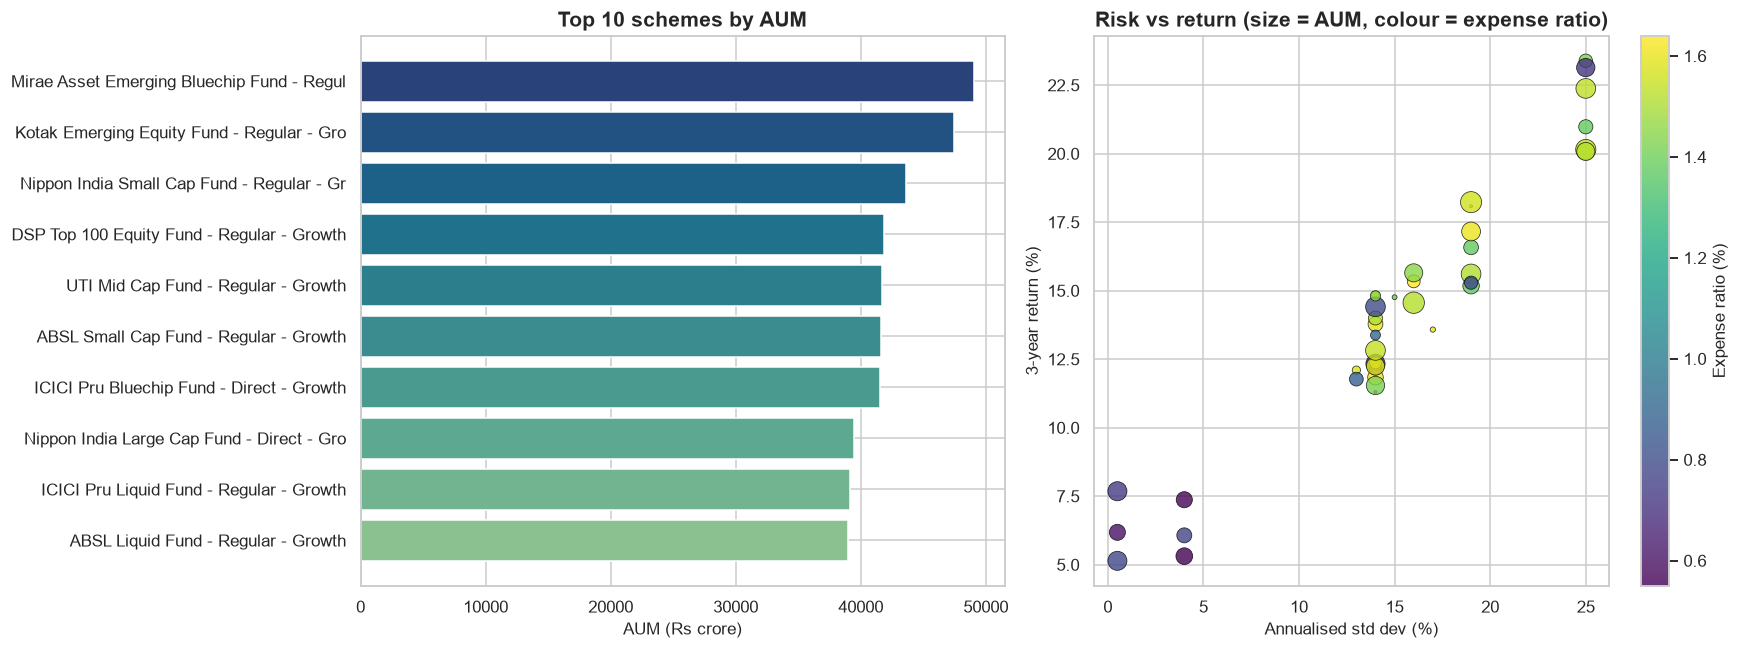

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_aum = perf.nlargest(10, "aum_crore")
axes[0].barh(top_aum["scheme_name"].str[:42][::-1], top_aum["aum_crore"][::-1],
             color=sns.color_palette("crest", 10))
axes[0].set(title="Top 10 schemes by AUM", xlabel="AUM (Rs crore)")

risk = perf.dropna(subset=["std_dev_ann_pct", "return_3yr_pct"])
sc = axes[1].scatter(risk["std_dev_ann_pct"], risk["return_3yr_pct"],
                     c=risk["expense_ratio_pct"], s=risk["aum_crore"] / 250,
                     cmap="viridis", alpha=0.8, edgecolor="black", linewidth=0.5)
axes[1].set(title="Risk vs return (size = AUM, colour = expense ratio)",
            xlabel="Annualised std dev (%)", ylabel="3-year return (%)")
plt.colorbar(sc, ax=axes[1], label="Expense ratio (%)")

plt.tight_layout()
save_png(fig, "14_aum_and_risk_return")
plt.show()

## 12. Ten key findings

In [18]:
# numbers quoted in the findings below, computed instead of typed by hand
yoy = sip.dropna(subset=["yoy_growth_pct"])["yoy_growth_pct"]
latest_aum = aum[aum.date_key == aum.date_key.max()].sort_values("aum_crore", ascending=False)
sip_val = txn[txn.transaction_type == "SIP"].groupby("age_group").amount_inr.sum()
tier_val = txn.groupby("city_tier").amount_inr.sum()
state_val = txn.groupby("state").amount_inr.sum().sort_values(ascending=False)
red = txn[txn.transaction_type == "Redemption"].amount_inr.sum()
inflow = txn[txn.transaction_type != "Redemption"].amount_inr.sum()

print(f"F1  SIP Jan22 -> Dec25      : {sip.sip_inflow_crore.iloc[0]:,.0f} -> {sip.sip_inflow_crore.iloc[-1]:,.0f} Cr  ({sip.sip_inflow_crore.iloc[-1]/sip.sip_inflow_crore.iloc[0]-1:+.1%})")
print(f"F2  mean SIP YoY growth     : {yoy.mean():.1f}%  (min {yoy.min():.1f}%, max {yoy.max():.1f}%)")
print(f"F3  SBI AUM / top-10 share  : {latest_aum.aum_lakh_crore.iloc[0]:.2f} L Cr, {100*latest_aum.aum_crore.iloc[0]/latest_aum.aum_crore.sum():.1f}%")
print(f"F4  top-3 house concentration: {100*latest_aum.aum_crore.head(3).sum()/latest_aum.aum_crore.sum():.1f}%")
print(f"F5  folios                  : {fol.total_folios_crore.iloc[0]} -> {fol.total_folios_crore.iloc[-1]} Cr ({fol.total_folios_crore.iloc[-1]/fol.total_folios_crore.iloc[0]-1:+.1%})")
print(f"F6  26-35 share of SIP value: {100*sip_val['26-35']/sip_val.sum():.1f}%")
print(f"F7  T30 share of value      : {100*tier_val['T30']/tier_val.sum():.1f}%   B30 {100*tier_val['B30']/tier_val.sum():.1f}%")
print(f"F8  top state               : {state_val.index[0]} ({100*state_val.iloc[0]/state_val.sum():.1f}%); top-3 {100*state_val.head(3).sum()/state_val.sum():.1f}%")
print(f"F9  redemption ratio        : {100*red/inflow:.1f}%")
print(f"F10 mean return correlation : {off.mean():+.4f}")
print(f"F11 direct vs regular TER   : {fund[fund.plan=='Direct'].expense_ratio_pct.mean():.3f}% vs {fund[fund.plan=='Regular'].expense_ratio_pct.mean():.3f}%")
print(f"F12 negative category-months: {int((cat.net_inflow_crore<0).sum())} of {len(cat)}")

F1  SIP Jan22 -> Dec25      : 11,517 -> 31,002 Cr  (+169.2%)
F2  mean SIP YoY growth     : 31.5%  (min 15.8%, max 53.0%)
F3  SBI AUM / top-10 share  : 12.50 L Cr, 19.9%
F4  top-3 house concentration: 51.9%
F5  folios                  : 13.26 -> 26.12 Cr (+97.0%)
F6  26-35 share of SIP value: 40.8%
F7  T30 share of value      : 65.9%   B30 34.1%
F8  top state               : Punjab (9.0%); top-3 26.7%
F9  redemption ratio        : 54.7%
F10 mean return correlation : -0.0027
F11 direct vs regular TER   : 0.780% vs 1.351%
F12 negative category-months: 0 of 144


### Findings

**1. SIP inflows nearly tripled in four years and ended at an all-time high.**
Monthly SIP contribution went from Rs 11,517 crore (Jan 2022) to Rs 31,002 crore
(Dec 2025), up 169%, with the peak in the last month of the series.
Chart: `04_sip_inflow_timeseries`.

**2. SIP growth is fast but slowing down.**
YoY growth averages about 31% across the 36 months that have a prior-year base, but the
trend falls away from the 2023 peak. The rupee increase keeps growing while the
percentage increase shrinks. Chart: `05_sip_yoy_growth`.

**3. SBI leads AUM at Rs 12.5 lakh crore, but its lead is narrowing.**
SBI holds about 20% of the ten houses' combined AUM. Its 21.3% CAGR over the window is
below Mirae (31.1%) and Nippon (28.9%), so the smaller houses are growing faster from a
lower base. Chart: `03_aum_by_fund_house`, query 8.

**4. The industry is concentrated.** The top three houses (SBI, ICICI Prudential, HDFC)
hold about 52% of the total AUM across the ten. Chart: `03_aum_by_fund_house`.

**5. Folio count doubled while the equity share stayed flat.**
Total folios grew from 13.26 to 26.12 crore (+97%) and equity's share stayed at exactly
70.0% throughout, so the growth came from more investors rather than a change in
preference. Chart: `10_folio_growth`.

**6. The 26-35 group is the core SIP market.**
They contribute about 41% of SIP value, more than the 46-55 and 56+ groups combined,
even though their median instalment is close to the all-ages median. Reach drives this,
not ticket size. Charts: `07_demographics_age_gender`, `08_sip_amount_by_age`.

**7. B30 is a third of transaction value.**
B30 cities account for about 34% against T30's 66%. This is the segment SEBI incentivises
and it is already material. Chart: `09_geographic_distribution`.

**8. Geographic spread is unusually even.**
No state is above 9% of SIP value and the top three together only reach about 27%. Real
Indian MF flows are far more concentrated - Maharashtra alone usually exceeds 25%. See
the caveat below. Chart: `09_geographic_distribution`.

**9. Redemptions offset more than half of gross inflow.**
Rs 0.55 leaves for every Rs 1.00 that comes in, so net flow is roughly 45% of the
headline gross figure. Reporting gross SIP numbers alone overstates what is retained.
Chart: `13_supporting_charts`, query 7.

**10. Daily returns across the ten largest funds are uncorrelated (mean r about 0.00).**
Real large-cap equity funds in one market correlate 0.75-0.95 because they hold
overlapping stocks. A mean correlation of zero, with the full pairwise range inside
+/-0.08, means these NAV series were generated independently of each other and of the
benchmark. Chart: `11_return_correlation_matrix`.

---

### Caveat

Findings 1-9 describe the dataset accurately and the charts are correct, but four things
point to this being synthetic data rather than observed market data:

| Signature | Observed | Real-world expectation |
|---|---|---|
| Fund-to-fund return correlation | about 0.00 | 0.75-0.95 |
| Fund returns vs NIFTY 50, 2024 | funds +13.7%, index -15.7% | funds track the index closely |
| Category-months with net outflow | 0 of 144 | routinely 10-25% of months |
| Payment-mode split | 25.2 / 25.1 / 24.9 / 24.9% | strongly skewed to UPI/mandate |

This matters for `Performance_Analytics.ipynb`: beta and alpha regressed on the benchmark
are not meaningful here because there is no real relationship for the regression to find.
They are computed as specified and reported next to their R-squared, which is what makes
the problem visible. Rankings within the fund universe (Sharpe, Sortino, drawdown,
scorecard) are still valid, since they compare the funds against each other rather than
against a market this data does not model.